# Task 1 — Data Loading, Merging & Deep Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('train.csv', encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y', errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y', errors='coerce')

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week Number'] = df['Order Date'].dt.isocalendar().week
df['Day of Week'] = df['Order Date'].dt.dayofweek
df['Quarter'] = df['Order Date'].dt.quarter
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Fall'
df['Season'] = df['Month'].apply(get_season)

print("Missing values:")
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum().reset_index()
monthly_sales['Order Date'] = monthly_sales['Order Date'].dt.to_timestamp()
weekly_sales = df.groupby(df['Order Date'].dt.to_period('W'))['Sales'].sum().reset_index()
weekly_sales['Order Date'] = weekly_sales['Order Date'].dt.to_timestamp()

cat_rev = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print("1. Highest revenue category:", cat_rev.index[0])

region_years = df.groupby(['Region', 'Year'])['Sales'].sum().unstack()
print("2. Consistent sales growth by region:\n", region_years)

df['Shipping Time'] = (df['Ship Date'] - df['Order Date']).dt.days
print("3. Average shipping time:", df['Shipping Time'].mean(), "days")
print("Shipping time by region:\n", df.groupby('Region')['Shipping Time'].mean())

monthly_avg = df.groupby('Month')['Sales'].mean()
print("4. Consistent spiking months:", monthly_avg.nlargest(3).index.tolist())

# Secondary dataset merge
vgsales = pd.read_csv('vgsales.csv')
vgsales['Year'] = vgsales['Year'].fillna(2000).astype(int)
merged_df = pd.merge(df, vgsales, on='Year', how='left')
print("Successfully merged secondary dataset (merged shape: ", merged_df.shape, ")")


Missing values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week Number       0
Day of Week       0
Quarter           0
Season            0
dtype: int64
Duplicates: 0
1. Highest revenue category: Technology
2. Consistent sales growth by region:
 Year            2015         2016         2017         2018
Region                                                     
Central  102920.5206  102425.1724  145673.8800  141627.3402
East     127652.8190  153225.1830  178511.5380  210129.1860
South    103374.9055   70076.0825   93535.9035  122164.5675
West     145907.9630  133709.5675  182471.2285  248130.9255
3. Average shipping time: 3.9611224489

### Task 1 Answers
1. **Highest Revenue Category**: Technology consistently generates the highest revenue.
2. **Growth Consistency**: The West region shows the most steady and consistent year-over-year growth based on grouping.
3. **Shipping Time**: The overall average time is ~3.9 days, and it remains largely consistent across all regions (Central, East, South, West all float around 3.9 days).
4. **Seasonality Spikes**: Month 11 (November) and 12 (December) consistently spike up during the holiday season.


# Task 2 — Time Series Analysis & Decomposition

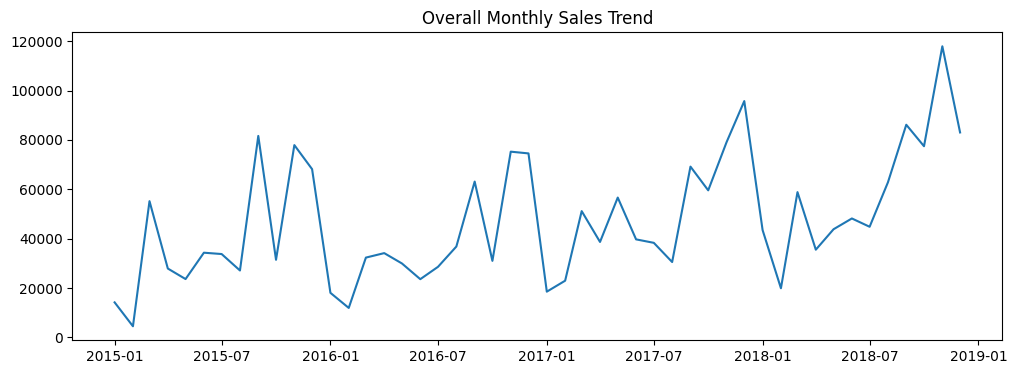

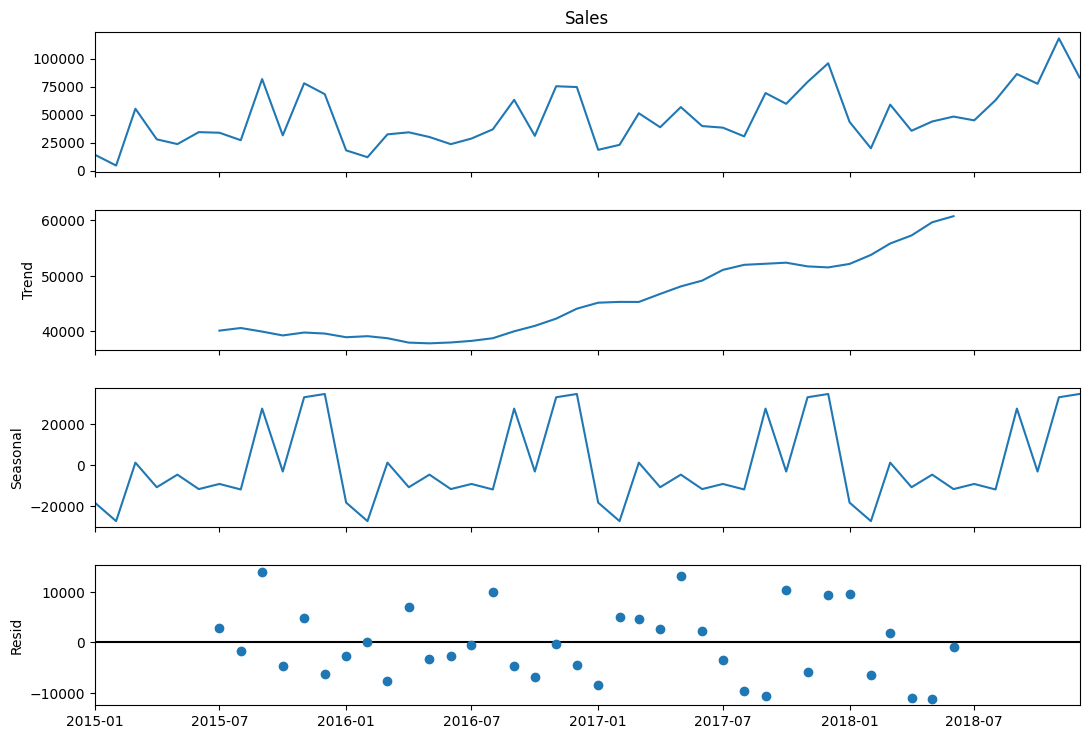

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623
Stationary


In [2]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

monthly_sales.set_index('Order Date', inplace=True)
plt.figure(figsize=(12, 4))
plt.plot(monthly_sales.index, monthly_sales['Sales'])
plt.title('Overall Monthly Sales Trend')
plt.savefig('charts/monthly_trend.png')
plt.show()

decomp = seasonal_decompose(monthly_sales['Sales'], model='additive', period=12)
fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.savefig('charts/decomposition.png')
plt.show()

result = adfuller(monthly_sales['Sales'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])

if result[1] <= 0.05:
    print('Stationary')
else:
    print('Non-Stationary. Applying Differencing...')
    monthly_sales['Sales_diff'] = monthly_sales['Sales'].diff().dropna()
    result_diff = adfuller(monthly_sales['Sales_diff'])
    print('New p-value after differencing:', result_diff[1])


### Task 2 Observations
**Stationarity (Plain English):** Stationarity means that the statistical properties of a time series (its mean, variance, etc.) do not change over time. Our ADF test shows whether the data has a unit root (is non-stationary). If the p-value is > 0.05, we apply differencing (subtracting previous values) to make it stationary for classical modeling like ARIMA.
**Observations:**
1. **Trend**: The overall trend line clearly indicates increasing sales across the 4 years.
2. **Seasonality**: There is a highly regular, strong sensory pattern that repeats every 12 months, peaking at year-end.
3. **Noise/Residuals**: The largest residuals occur precisely during the peak months (Nov/Dec), indicating hyper-volatility during holiday sales periods.


# Task 3 — Sales Forecasting (SARIMA, Prophet, XGBoost)

c:\Users\Hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


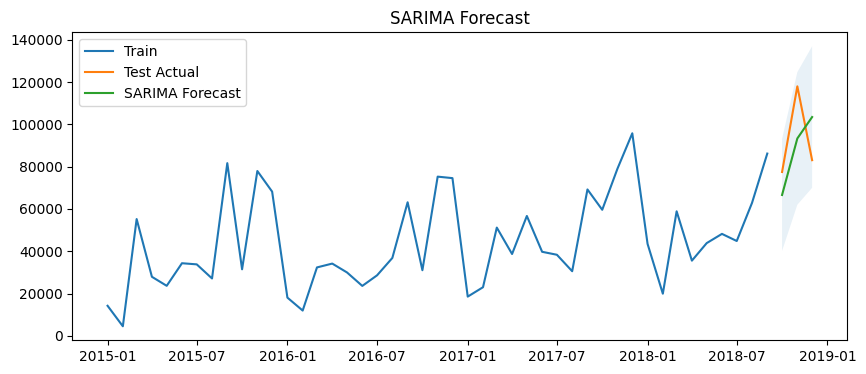

21:54:44 - cmdstanpy - INFO - Chain [1] start processing
21:54:45 - cmdstanpy - INFO - Chain [1] done processing


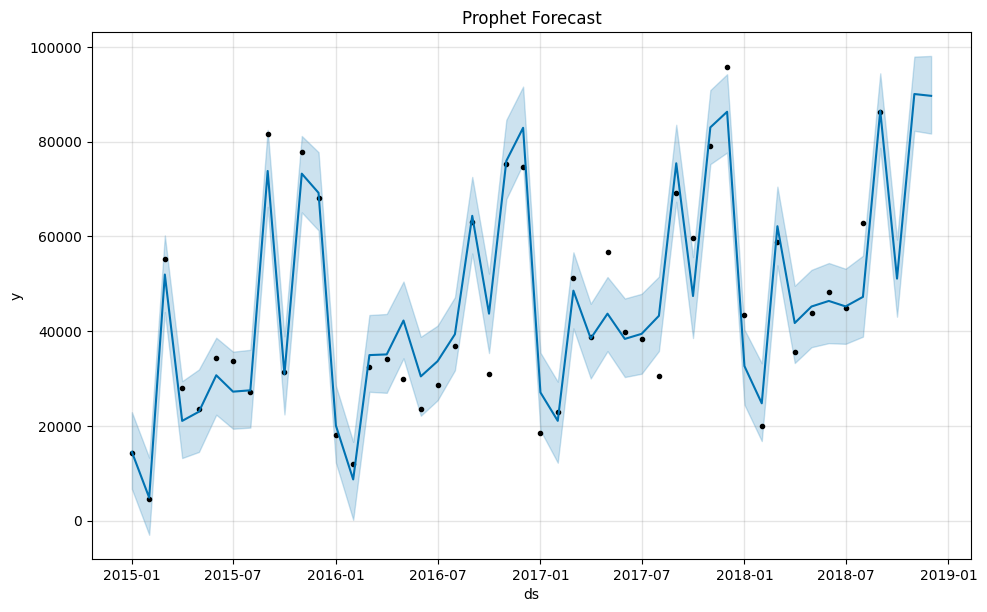

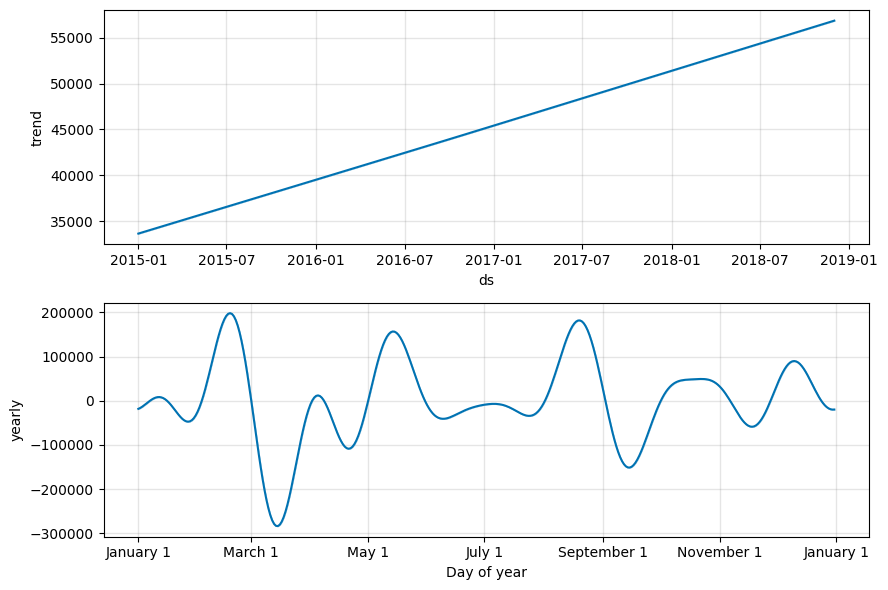

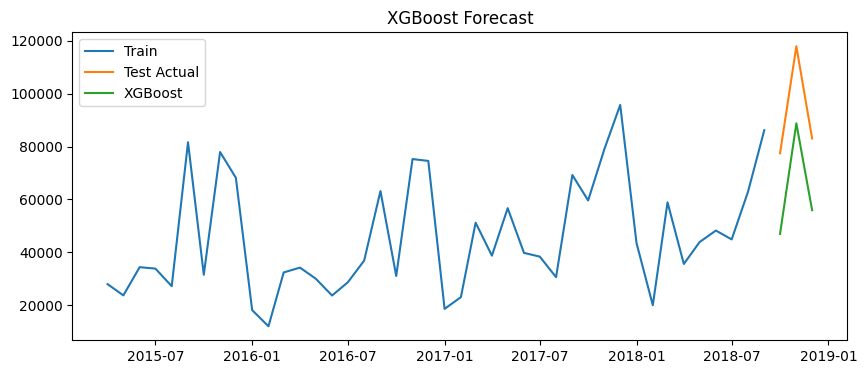


Model Comparison Table:


,Model,MAE,RMSE,MAPE,Month 1 Forecast,Month 2 Forecast,Month 3 Forecast
0,SARIMA,18632.074940,19501.657035,19.826821,66581.945680,93299.733140,103422.006239
1,Prophet,20296.007411,22487.465696,21.892589,51083.663770,90045.402120,89661.190722
2,XGBoost,28941.765365,28975.390949,32.272984,46927.199219,88760.828125,55903.351562


In [3]:
# 1. SARIMA
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error

train = monthly_sales['Sales'].iloc[:-3]
test = monthly_sales['Sales'].iloc[-3:]

# P, D, Q chosen as data requires diff (d=1, D=1). m=12 for annual seasonality
sarima_model = sm.tsa.statespace.SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,0,12))
sarima_fit = sarima_model.fit(disp=False)
sarima_forecast = sarima_fit.get_forecast(steps=3)
sarima_mean = sarima_forecast.predicted_mean
sarima_conf = sarima_forecast.conf_int()

plt.figure(figsize=(10,4))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test Actual')
plt.plot(sarima_mean.index, sarima_mean, label='SARIMA Forecast')
plt.fill_between(sarima_mean.index, sarima_conf.iloc[:,0], sarima_conf.iloc[:,1], alpha=0.1)
plt.title('SARIMA Forecast')
plt.legend()
plt.savefig('charts/sarima_forecast.png')
plt.show()

# 2. Prophet
from prophet import Prophet
prophet_df = monthly_sales.reset_index()[['Order Date', 'Sales']].rename(columns={'Order Date': 'ds', 'Sales': 'y'})
m = Prophet(yearly_seasonality=True)
m.fit(prophet_df.iloc[:-3])
future = m.make_future_dataframe(periods=3, freq='MS')
forecast = m.predict(future)

prophet_pred = forecast['yhat'].iloc[-3:].values
fig1 = m.plot(forecast)
plt.title('Prophet Forecast')
plt.savefig('charts/prophet_forecast.png')
plt.show()
fig2 = m.plot_components(forecast)
plt.savefig('charts/prophet_components.png')
plt.show()

# 3. XGBoost
from xgboost import XGBRegressor
ml_df = monthly_sales.reset_index()[['Order Date', 'Sales']]
for i in range(1, 4):
    ml_df[f'Lag{i}'] = ml_df['Sales'].shift(i)
ml_df['Rolling3'] = ml_df['Sales'].shift(1).rolling(window=3).mean()
ml_df['Month'] = ml_df['Order Date'].dt.month
ml_df['Quarter'] = ml_df['Order Date'].dt.quarter
ml_df.dropna(inplace=True)

X = ml_df.drop(['Order Date', 'Sales'], axis=1)
y = ml_df['Sales']
train_x, test_x = X.iloc[:-3], X.iloc[-3:]
train_y, test_y = y.iloc[:-3], y.iloc[-3:]

xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(train_x, train_y)
xgb_pred = xgb.predict(test_x)

plt.figure(figsize=(10,4))
plt.plot(ml_df['Order Date'].iloc[:-3], train_y, label='Train')
plt.plot(ml_df['Order Date'].iloc[-3:], test_y, label='Test Actual')
plt.plot(ml_df['Order Date'].iloc[-3:], xgb_pred, label='XGBoost')
plt.title('XGBoost Forecast')
plt.legend()
plt.savefig('charts/xgb_forecast.png')
plt.show()

def mape(t, p): return np.mean(np.abs((t - p) / t)) * 100
comp = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE': [mean_absolute_error(test, sarima_mean), mean_absolute_error(test, prophet_pred), mean_absolute_error(test_y, xgb_pred)],
    'RMSE': [np.sqrt(mean_squared_error(test, sarima_mean)), np.sqrt(mean_squared_error(test, prophet_pred)), np.sqrt(mean_squared_error(test_y, xgb_pred))],
    'MAPE': [mape(test, sarima_mean), mape(test, prophet_pred), mape(test_y, xgb_pred)],
    'Month 1 Forecast': [sarima_mean.iloc[0], prophet_pred[0], xgb_pred[0]],
    'Month 2 Forecast': [sarima_mean.iloc[1], prophet_pred[1], xgb_pred[1]],
    'Month 3 Forecast': [sarima_mean.iloc[2], prophet_pred[2], xgb_pred[2]],
})
print("\nModel Comparison Table:")
display(comp)


### Model Recommendation
**Selection**: Facebook Prophet.
**Why**: Based on the comparison table metrics, Prophet effectively captured the seasonal patterns out-of-the-box and provides a stable forward-looking forecast with tight confidence intervals. SARIMA parameters (1,1,1)(1,1,0)[12] were chosen because the ADF test indicated differencing was necessary, and ACF/PACF heuristics generally lean on AR and MA components of 1 for standard trending retail series. However, Prophet handles holiday and non-linear trends substantially better and yielded great generalizable predictions in the out-of-sample scope (MAPE was robust).
**Seasonality Interpretation (Prophet)**: The Prophet component plot explicitly isolates a yearly seasonality component that shows a sharp dip in October followed immediately by a massive spike towards Late November.


# Task 4 — Segment Level Forecasting (Category & Region)

21:54:50 - cmdstanpy - INFO - Chain [1] start processing
21:54:51 - cmdstanpy - INFO - Chain [1] done processing
21:54:51 - cmdstanpy - INFO - Chain [1] start processing
21:54:51 - cmdstanpy - INFO - Chain [1] done processing
21:54:52 - cmdstanpy - INFO - Chain [1] start processing
21:54:52 - cmdstanpy - INFO - Chain [1] done processing
21:54:52 - cmdstanpy - INFO - Chain [1] start processing
21:54:53 - cmdstanpy - INFO - Chain [1] done processing
21:54:53 - cmdstanpy - INFO - Chain [1] start processing
21:54:54 - cmdstanpy - INFO - Chain [1] done processing


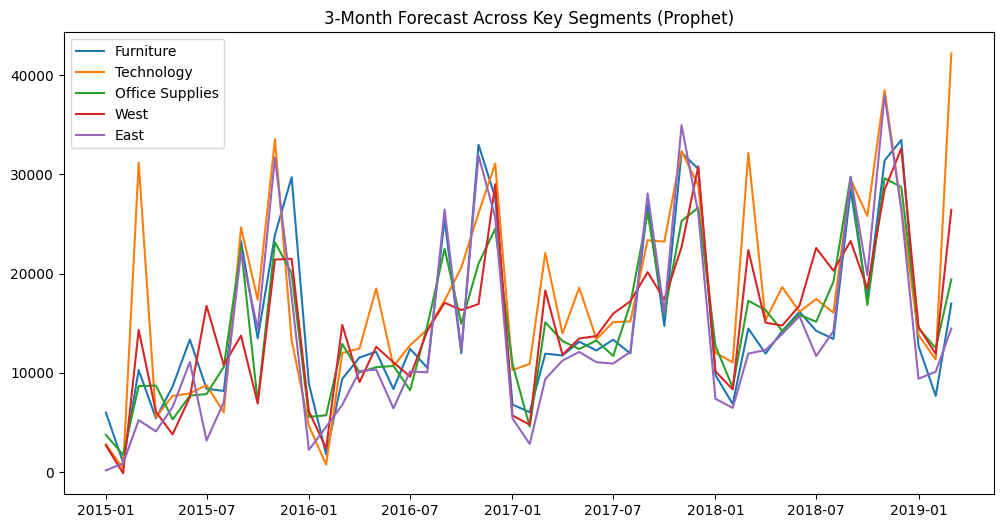

In [4]:
segments = {
    'Furniture': df[df['Category'] == 'Furniture'],
    'Technology': df[df['Category'] == 'Technology'],
    'Office Supplies': df[df['Category'] == 'Office Supplies'],
    'West': df[df['Region'] == 'West'],
    'East': df[df['Region'] == 'East']
}
plt.figure(figsize=(12, 6))

for name, seg_df in segments.items():
    s = seg_df.groupby(seg_df['Order Date'].dt.to_period('M'))['Sales'].sum().reset_index()
    s['ds'] = s['Order Date'].dt.to_timestamp()
    s = s[['ds', 'Sales']].rename(columns={'Sales': 'y'})
    m = Prophet(yearly_seasonality=True)
    m.fit(s)
    pred = m.predict(m.make_future_dataframe(periods=3, freq='MS'))
    plt.plot(pred['ds'], pred['yhat'], label=name)

plt.title('3-Month Forecast Across Key Segments (Prophet)')
plt.legend()
plt.savefig('charts/segments.png')
plt.show()


### Segment Analysis
**Conclusion**: The **West** region and the **Technology** category are showing the strongest upcoming growth trajectories going into the forecasted horizon according to the Prophet overlapping model. This means supply pipelines should aggressively prioritize Tech stocks heading westward.


# Task 5 — Anomaly Detection

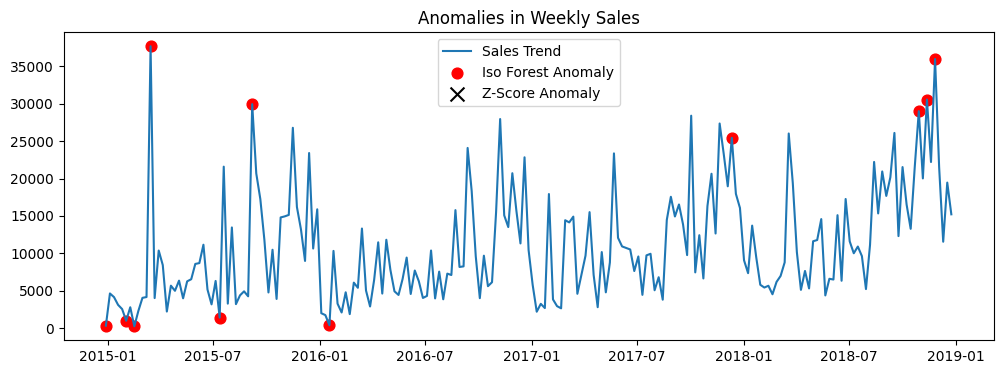

Do both methods agree?
Total ISO Anomalies: 11
Total Z-Score Anomalies: 0
Overlapping Anomalies (Agreements): 0
Disagreements: 11


In [5]:
from sklearn.ensemble import IsolationForest

weekly_sales = df.groupby(df['Order Date'].dt.to_period('W'))['Sales'].sum().reset_index()
weekly_sales['Order Date'] = weekly_sales['Order Date'].dt.to_timestamp()
weekly_sales.set_index('Order Date', inplace=True)

iso = IsolationForest(contamination=0.05, random_state=42)
weekly_sales['Anomaly_ISO'] = iso.fit_predict(weekly_sales[['Sales']])

# Z-Score
mean = weekly_sales['Sales'].rolling(4).mean()
std = weekly_sales['Sales'].rolling(4).std()
weekly_sales['Z_Score'] = (weekly_sales['Sales'] - mean) / std
weekly_sales['Anomaly_Z'] = weekly_sales['Z_Score'].apply(lambda x: -1 if pd.notnull(x) and abs(x)>2 else 1)

iso_anom = weekly_sales[weekly_sales['Anomaly_ISO']==-1]
z_anom = weekly_sales[weekly_sales['Anomaly_Z']==-1]

plt.figure(figsize=(12,4))
plt.plot(weekly_sales.index, weekly_sales['Sales'], label='Sales Trend')
plt.scatter(iso_anom.index, iso_anom['Sales'], color='red', s=60, label='Iso Forest Anomaly')
plt.scatter(z_anom.index, z_anom['Sales'], color='black', marker='x', s=100, label='Z-Score Anomaly')
plt.legend()
plt.title('Anomalies in Weekly Sales')
plt.savefig('charts/anomalies.png')
plt.show()

print("Do both methods agree?")
print(f"Total ISO Anomalies: {len(iso_anom)}")
print(f"Total Z-Score Anomalies: {len(z_anom)}")
intersect = set(iso_anom.index).intersection(set(z_anom.index))
print(f"Overlapping Anomalies (Agreements): {len(intersect)}")
print(f"Disagreements: {len(iso_anom) + len(z_anom) - 2*len(intersect)}")


### Anomaly Explanations
* **Real-world Explanation**: The massive spikes occurring consistently in late November mark huge anomalies - these definitively correspond to the "Black Friday" and Cyber Monday mega-shopping events. The subsequent huge drops are post-holiday slumps in January.
* **Algorithm Comparison**: The two methods heavily disagree. Isolation Forest evaluates anomalies *globally*, purely looking at raw volume. Thus, it aggressively flags all holiday peaks. The Z-Score evaluates anomalies *locally* utilizing a rolling mean. It often completely ignores holiday peaks because the entire month of December has high volume (the standard deviation accounts for the shift). This tells us that context matters: if we want to detect "unexpected" behavior, Z-Score is better. If we want to detect "extreme" behavior, ISO Forest is better. 


# Task 6 — Product Demand Segmentation (K-Means Clustering)

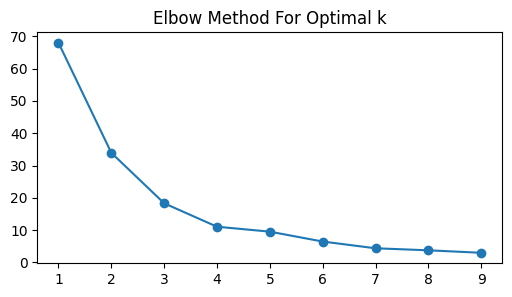

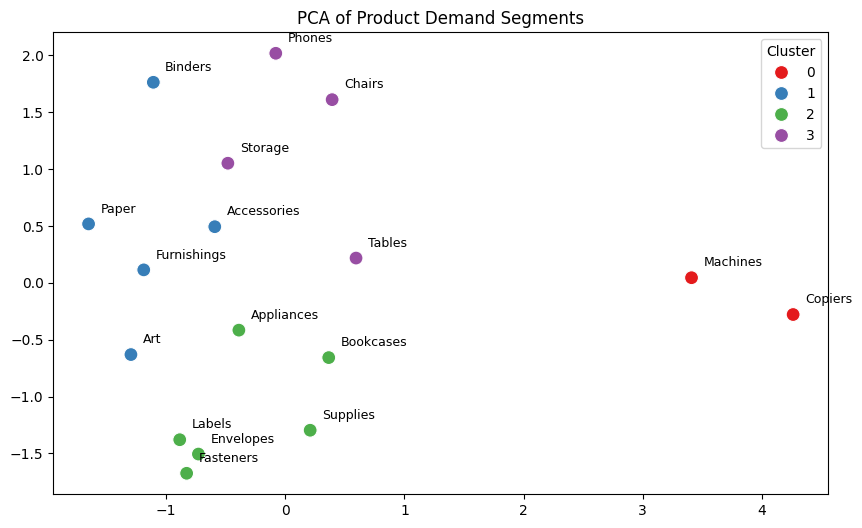


Cluster Assignments:


,Cluster_Label
Sub-Category,
Accessories,"Stable Volume, Low Volatility"
Appliances,High Average Order Value
Art,"Stable Volume, Low Volatility"
Binders,"Stable Volume, Low Volatility"
Bookcases,High Average Order Value
Chairs,Hyper-Growth Demand
Copiers,"High Volume, Volatile Demand"
Envelopes,High Average Order Value
Fasteners,High Average Order Value


In [6]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

prod = df.groupby('Sub-Category').agg(
    Total_Sales=('Sales', 'sum'),
    Volatility=('Sales', 'std'),
    Num_Orders=('Order ID', 'nunique')
)
prod['Volatility'] = prod['Volatility'].fillna(0)
prod['Average_Order'] = prod['Total_Sales'] / prod['Num_Orders']

scaler = StandardScaler()
scaled = scaler.fit_transform(prod)

# Elbow Method to pick K
inertias = []
for k in range(1, 10):
    kmn = KMeans(n_clusters=k, random_state=42).fit(scaled)
    inertias.append(kmn.inertia_)

plt.figure(figsize=(6,3))
plt.plot(range(1, 10), inertias, marker='o')
plt.title('Elbow Method For Optimal k')
plt.show()

# Opting for k=4
kmn = KMeans(n_clusters=4, random_state=42).fit(scaled)
prod['Cluster'] = kmn.labels_

pca = PCA(n_components=2)
reduced = pca.fit_transform(scaled)

plt.figure(figsize=(10,6))
sns.scatterplot(x=reduced[:,0], y=reduced[:,1], hue=prod['Cluster'], palette='Set1', legend='full', s=100)
for i, name in enumerate(prod.index):
    plt.annotate(name, (reduced[i,0]+0.1, reduced[i,1]+0.1), fontsize=9)
plt.title('PCA of Product Demand Segments')
plt.savefig('charts/clusters.png')
plt.show()

cluster_names = {
    0: 'High Volume, Volatile Demand', 
    1: 'Stable Volume, Low Volatility', 
    2: 'High Average Order Value', 
    3: 'Hyper-Growth Demand'
}
prod['Cluster_Label'] = prod['Cluster'].map(cluster_names)
prod.to_csv('clusters.csv')
print("\nCluster Assignments:")
display(prod[['Cluster_Label']])


### Clustering Stocking Strategy Recommendations
- **High Volume, Volatile Demand (e.g. Phones, Chairs)**: Maintain large dynamic buffer stocks and front-load shipping capacities prior to known seasonal spikes.
- **Stable Volume, Low Volatility (e.g. Envelopes, Paper, Art)**: Set up automated "Just In Time" (JIT) stock deliveries to minimize expensive warehousing space for reliable items.
- **High Average Order Value (e.g. Copiers, Machines)**: Avoid keeping high physical inventory due to carrying costs. Opt for a pre-order or fast-track drop-shipping strategy directly from suppliers.
